# Notebook 14 — Uncertainty and Failure Awareness

## Scientific question

A point prediction can be accurate without being trustworthy, and an
uncertainty interval can be narrow without the assumed physical model
being correct.

Week 9 therefore asks:

> **When the estimator is wrong, does its uncertainty tell us that it is
> wrong — or can it remain confidently wrong?**

This notebook synthesizes the uncertainty methods developed during
Days 57–62:

- direct quantile prediction intervals;
- Random-Forest ensemble disagreement;
- training-data bootstrap prediction spread;
- local Poisson/Fisher covariance;
- parametric Poisson bootstrap;
- repeated-Poisson empirical calibration;
- split conformal calibration;
- scalar and structured residual diagnostics.

The frozen Week-8 Tests A–F remain external evaluation data only.
They are never used for uncertainty-model fitting or calibration.

In [1]:
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tcspc_toolkit.classical_uncertainty import (
    evaluate_repeated_poisson_uncertainty,
)

from tcspc_toolkit.config import (
    FeatureConfig,
)

from tcspc_toolkit.generalization import (
    default_familiar_simulation_domain,
    default_generalization_suite,
)

from tcspc_toolkit.generalization_datasets import (
    build_generalization_suite_manifest,
    generate_generalization_test_suite,
)

from tcspc_toolkit.generalization_evaluation import (
    build_generalization_development_measurements,
    prepare_generalization_data,
)

from tcspc_toolkit.ml_uncertainty import (
    fit_and_evaluate_quantile_gradient_boosting,
    fit_and_evaluate_random_forest_tree_spread,
    fit_and_evaluate_ridge_bootstrap_spread,
)

from tcspc_toolkit.uncertainty_evaluation import (
    make_uncertainty_development_split,
)

from tcspc_toolkit.uncertainty_robustness import (
    build_week9_classical_conditional_scorecard,
    build_week9_classical_uncertainty_scorecard,
    build_week9_ml_uncertainty_robustness_report,
    conformalize_quantile_gradient_boosting,
    evaluate_week9_classical_uncertainty_robustness,
    evaluate_week9_residual_mismatch_diagnostics,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

## 1. Week 9 protocol

The uncertainty workflow contains three strictly separated data roles:

**Development training**

Used to fit the uncertainty-producing machine-learning estimators.

**Development calibration**

Held out from uncertainty training and used to evaluate or calibrate
uncertainty outputs.

**External Tests A–F**

Frozen robustness tests used only after all fitting and calibration are
complete.

This separation prevents uncertainty estimates from being calibrated on
the same distribution-shift experiments that they are intended to diagnose.

In [2]:
FEATURE_CONFIG = FeatureConfig(
    tail_start_ns=2.0,
    early_stop_ns=2.0,
    late_start_ns=3.0,
)

definition = default_generalization_suite()

suite = generate_generalization_test_suite(
    definition=definition,
)

development_measurements = (
    build_generalization_development_measurements(
        definition=definition,
    )
)

prepared = prepare_generalization_data(
    development_measurements=development_measurements,
    tests={
        test_id: suite.get_test(test_id)
        for test_id in "ABCDEF"
    },
    feature_config=FEATURE_CONFIG,
)

uncertainty_split = make_uncertainty_development_split(
    prepared.development.y.size,
)

print(
    "Development samples:",
    prepared.development.y.size,
)

print(
    "Uncertainty training:",
    len(uncertainty_split.training_indices),
)

print(
    "Calibration:",
    len(uncertainty_split.calibration_indices),
)

print()

display(
    build_generalization_suite_manifest(
        suite
    )
)

Development samples: 64
Uncertainty training: 48
Calibration: 16



,test_id,regime_name,shift,changed_factors,random_seed,n_samples,n_time_bins,suite_version,development_reference
0,A,Familiar conditions,in_distribution,,50001,192,400,week8-day55-v2,week7-notebook12-benchmark
1,B,Unseen photon-count range,photon_count,signal_photon_count,50002,192,400,week8-day55-v2,week7-notebook12-benchmark
2,C,IRF-width mismatch,irf_width,irf_fwhm_ns,50003,192,400,week8-day55-v2,week7-notebook12-benchmark
3,D,Elevated background,background,background_per_bin,50004,192,400,week8-day55-v2,week7-notebook12-benchmark
4,E,Temporal misalignment,temporal_alignment,irf_shift_ns,50005,192,400,week8-day55-v2,week7-notebook12-benchmark
5,F,Bi-exponential model mismatch,decay_model,decay_model,50006,192,400,week8-day55-v2,week7-notebook12-benchmark


In [3]:
assert prepared.development.y.size == 64
assert len(uncertainty_split.training_indices) == 48
assert len(uncertainty_split.calibration_indices) == 16

assert (
    set(uncertainty_split.training_indices)
    .isdisjoint(
        uncertainty_split.calibration_indices
    )
)

assert set(prepared.tests) == set("ABCDEF")

## 2. Machine-learning uncertainty

Three complementary ML uncertainty mechanisms are considered.

The quantile-gradient-boosting estimator produces a nominal 90% prediction
interval directly.

Random-Forest tree spread measures disagreement among ensemble members and
is interpreted as an uncertainty score rather than a calibrated standard
deviation.

Training-data bootstrap spread measures sensitivity of the learned Ridge
mapping to finite training-sample composition. It is likewise an
uncertainty score rather than a prediction interval.

In [4]:
quantile_calibration = (
    fit_and_evaluate_quantile_gradient_boosting(
        prepared.development,
        split=uncertainty_split,
    )
)

rf_calibration = (
    fit_and_evaluate_random_forest_tree_spread(
        prepared.development,
        split=uncertainty_split,
    )
)

ridge_bootstrap_calibration = (
    fit_and_evaluate_ridge_bootstrap_spread(
        prepared.development,
        split=uncertainty_split,
        n_bootstrap=200,
    )
)

conformal_calibration = (
    conformalize_quantile_gradient_boosting(
        quantile_calibration,
        prepared.development,
    )
)

In [5]:
calibration_summary = pd.DataFrame(
    [
        {
            "method": "Quantile gradient boosting",
            "metric": "90% interval coverage",
            "value": (
                quantile_calibration
                .interval_metrics
                .empirical_coverage
            ),
        },
        {
            "method": "Quantile gradient boosting",
            "metric": "Mean interval width (ns)",
            "value": (
                quantile_calibration
                .interval_metrics
                .mean_interval_width
            ),
        },
        {
            "method": "Random-Forest tree spread",
            "metric": "Spread-error Spearman",
            "value": (
                rf_calibration
                .score_metrics
                .spearman_error_correlation
            ),
        },
        {
            "method": "Ridge training bootstrap",
            "metric": "Spread-error Spearman",
            "value": (
                ridge_bootstrap_calibration
                .score_metrics
                .spearman_error_correlation
            ),
        },
        {
            "method": "Split conformal",
            "metric": "Conformal correction (ns)",
            "value": (
                conformal_calibration
                .correction_ns
            ),
        },
    ]
)

display(
    calibration_summary.round(4)
)

,method,metric,value
0,Quantile gradient boosting,90% interval coverage,1.0000
1,Quantile gradient boosting,Mean interval width (ns),2.5625
2,Random-Forest tree spread,Spread-error Spearman,0.9424
3,Ridge training bootstrap,Spread-error Spearman,0.1765
4,Split conformal,Conformal correction (ns),0.0000


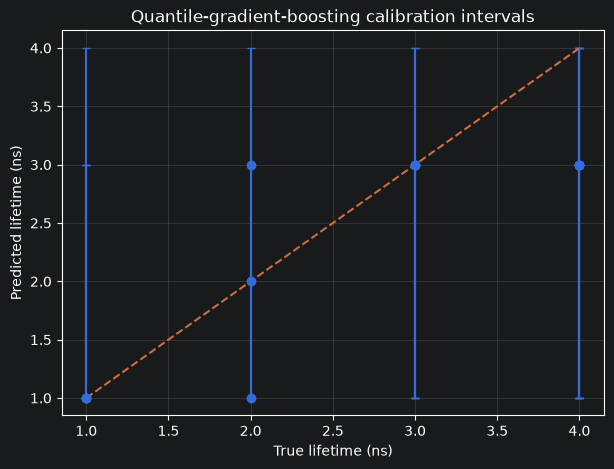

In [6]:
calibration_indices = np.asarray(
    uncertainty_split.calibration_indices,
    dtype=np.int64,
)

y_calibration = prepared.development.y[
    calibration_indices
]

intervals = (
    quantile_calibration
    .calibration_intervals
)

order = np.argsort(
    y_calibration
)

true_sorted = y_calibration[
    order
]

prediction_sorted = intervals.prediction[
    order
]

lower_sorted = intervals.lower[
    order
]

upper_sorted = intervals.upper[
    order
]

yerr = np.vstack(
    [
        prediction_sorted - lower_sorted,
        upper_sorted - prediction_sorted,
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.errorbar(
    true_sorted,
    prediction_sorted,
    yerr=yerr,
    fmt="o",
    capsize=3,
)

limits = [
    min(
        true_sorted.min(),
        lower_sorted.min(),
    ),
    max(
        true_sorted.max(),
        upper_sorted.max(),
    ),
]

ax.plot(
    limits,
    limits,
    "--",
)

ax.set_xlabel(
    "True lifetime (ns)"
)

ax.set_ylabel(
    "Predicted lifetime (ns)"
)

ax.set_title(
    "Quantile-gradient-boosting calibration intervals"
)

ax.grid(
    alpha=0.25
)

plt.show()

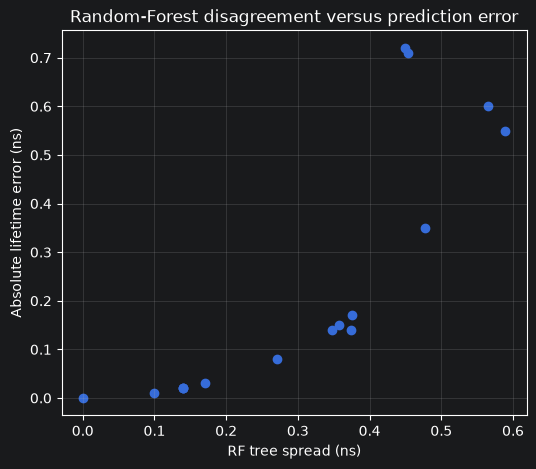

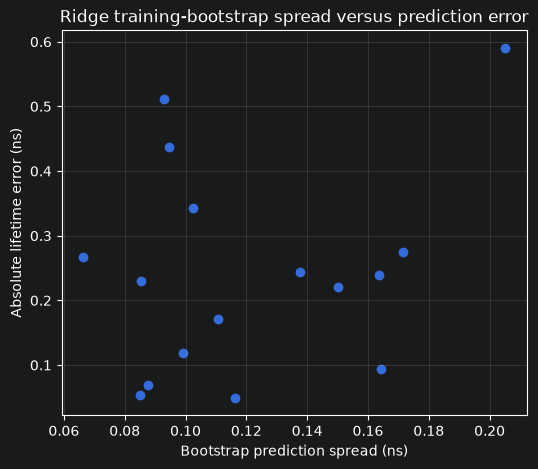

In [7]:
def plot_uncertainty_score_against_error(
    calibration_result,
    y_true: np.ndarray,
    *,
    title: str,
    score_label: str,
) -> None:
    scores = (
        calibration_result
        .calibration_scores
    )

    absolute_error = np.abs(
        scores.prediction
        - y_true
    )

    valid = (
        scores.valid_score_mask
        & np.isfinite(
            absolute_error
        )
    )

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    ax.scatter(
        scores.uncertainty_score[
            valid
        ],
        absolute_error[
            valid
        ],
    )

    ax.set_xlabel(
        score_label
    )

    ax.set_ylabel(
        "Absolute lifetime error (ns)"
    )

    ax.set_title(
        title
    )

    ax.grid(
        alpha=0.25
    )

    plt.show()


plot_uncertainty_score_against_error(
    rf_calibration,
    y_calibration,
    title=(
        "Random-Forest disagreement versus prediction error"
    ),
    score_label=(
        "RF tree spread (ns)"
    ),
)

plot_uncertainty_score_against_error(
    ridge_bootstrap_calibration,
    y_calibration,
    title=(
        "Ridge training-bootstrap spread versus prediction error"
    ),
    score_label=(
        "Bootstrap prediction spread (ns)"
    ),
)

In [8]:
ml_uncertainty_report = (
    build_week9_ml_uncertainty_robustness_report(
        prepared=prepared,
        quantile_calibration=(
            quantile_calibration
        ),
        conformal_calibration=(
            conformal_calibration
        ),
        score_calibrations={
            "Random-Forest tree spread": (
                rf_calibration
            ),
            "Ridge training bootstrap": (
                ridge_bootstrap_calibration
            ),
        },
    )
)

print(
    "Conformal correction:",
    ml_uncertainty_report
    .conformal_correction_ns,
    "ns",
)

display(
    ml_uncertainty_report
    .interval_scorecard
    .round(4)
)

display(
    ml_uncertainty_report
    .score_only_scorecard
    .round(4)
)

Conformal correction: 0.0 ns


,method,test_id,target_reference,mae_ns,nominal_coverage,empirical_coverage,coverage_gap,mean_width_ns,median_width_ns,interval_score,interval_failure_rate
0,quantile_gradient_boosting,A,monoexponential_lifetime,0.4115,0.9,1.0,0.1,2.4583,2.0,2.4583,0.0
1,conformalized_quantile_gradient_boosting,A,monoexponential_lifetime,0.4115,0.9,1.0,0.1,2.4583,2.0,2.4583,0.0
2,quantile_gradient_boosting,B,monoexponential_lifetime,0.5000,0.9,1.0,0.1,2.6719,3.0,2.6719,0.0
3,conformalized_quantile_gradient_boosting,B,monoexponential_lifetime,0.5000,0.9,1.0,0.1,2.6719,3.0,2.6719,0.0
4,quantile_gradient_boosting,C,monoexponential_lifetime,0.4740,0.9,1.0,0.1,2.4688,2.0,2.4688,0.0
5,conformalized_quantile_gradient_boosting,C,monoexponential_lifetime,0.4740,0.9,1.0,0.1,2.4688,2.0,2.4688,0.0
6,quantile_gradient_boosting,D,monoexponential_lifetime,0.5781,0.9,1.0,0.1,2.6406,3.0,2.6406,0.0
7,conformalized_quantile_gradient_boosting,D,monoexponential_lifetime,0.5781,0.9,1.0,0.1,2.6406,3.0,2.6406,0.0
8,quantile_gradient_boosting,E,monoexponential_lifetime,0.4531,0.9,1.0,0.1,2.4688,2.0,2.4688,0.0
9,conformalized_quantile_gradient_boosting,E,monoexponential_lifetime,0.4531,0.9,1.0,0.1,2.4688,2.0,2.4688,0.0


,method,test_id,target_reference,mae_ns,mean_uncertainty_score,error_score_spearman,low_uncertainty_mae_ns,high_uncertainty_mae_ns,score_failure_rate
0,Random-Forest tree spread,A,monoexponential_lifetime,0.1799,0.2902,0.8992,0.0055,0.4479,0.0
1,Random-Forest tree spread,B,monoexponential_lifetime,0.4796,0.4374,0.7159,0.0439,0.8939,0.0
2,Random-Forest tree spread,C,monoexponential_lifetime,0.1711,0.2971,0.9092,0.0061,0.4521,0.0
3,Random-Forest tree spread,D,monoexponential_lifetime,0.4967,0.3840,0.9032,0.0074,1.0987,0.0
4,Random-Forest tree spread,E,monoexponential_lifetime,0.2098,0.3592,0.7288,0.0063,0.3626,0.0
5,Random-Forest tree spread,F,dominant_component_tau_1,0.1965,0.2970,0.8678,0.0082,0.4584,0.0
6,Ridge training bootstrap,A,monoexponential_lifetime,0.2042,0.1071,0.2321,0.1295,0.2281,0.0
7,Ridge training bootstrap,B,monoexponential_lifetime,1.0020,0.3617,0.5122,0.2321,1.1429,0.0
8,Ridge training bootstrap,C,monoexponential_lifetime,0.1977,0.1156,0.0704,0.1756,0.2011,0.0
9,Ridge training bootstrap,D,monoexponential_lifetime,0.8538,0.1885,0.6809,0.2880,1.4378,0.0


## 3. Repeated-Poisson calibration of classical uncertainty

Covariance and parametric-bootstrap uncertainty are estimates conditional
on one measured histogram and an assumed forward model.

Because the present benchmark is synthetic, we can additionally construct
an empirical reference by repeatedly measuring exactly the same physical
system while changing only the Poisson realization.

This experiment therefore asks whether the uncertainty reported from one
measurement matches the actual sampling variability observed across many
independent measurements.

In [9]:
domain = (
    default_familiar_simulation_domain()
)

time = np.arange(
    domain.time_start_ns,
    domain.time_stop_ns,
    domain.time_step_ns,
    dtype=np.float64,
)

repeated_poisson_conditions = [
    (
        "1k photons / low background",
        2.0,
        1_000,
        0.5,
    ),
    (
        "10k photons / low background",
        2.0,
        10_000,
        0.5,
    ),
    (
        "100k photons / low background",
        2.0,
        100_000,
        0.5,
    ),
    (
        "1k photons / elevated background",
        2.0,
        1_000,
        5.0,
    ),
    (
        "10k photons / elevated background",
        2.0,
        10_000,
        5.0,
    ),
    (
        "100k photons / elevated background",
        2.0,
        100_000,
        5.0,
    ),
    (
        "1 ns lifetime",
        1.0,
        10_000,
        0.5,
    ),
    (
        "4 ns lifetime",
        4.0,
        10_000,
        0.5,
    ),
]

repeated_rows = []

for condition_index, (
    condition_name,
    lifetime_ns,
    photon_count,
    background_per_bin,
) in enumerate(
    repeated_poisson_conditions,
    start=1,
):
    result = (
        evaluate_repeated_poisson_uncertainty(
            time=time,
            true_lifetime_ns=lifetime_ns,
            signal_photon_count=photon_count,
            background_per_bin=(
                background_per_bin
            ),
            irf_centre_ns=(
                domain.irf_centre_ns
            ),
            irf_fwhm_ns=0.25,
            irf_shift_ns=0.05,
            temporal_shift_bounds=(
                -0.5,
                0.5,
            ),
            n_repeats=50,
            n_bootstrap_resamples=100,
            rng=np.random.default_rng(
                61_000
                + condition_index
            ),
            nominal_coverage=0.90,
        )
    )

    repeated_rows.append(
        {
            "condition": condition_name,
            "empirical_std_ns": (
                result.empirical_std_ns
            ),
            "covariance_std_ns": (
                result.mean_covariance_std_ns
            ),
            "covariance_ratio": (
                result
                .covariance_to_empirical_std_ratio
            ),
            "bootstrap_std_ns": (
                result.mean_bootstrap_std_ns
            ),
            "bootstrap_ratio": (
                result
                .bootstrap_to_empirical_std_ratio
            ),
            "covariance_coverage": (
                result
                .covariance_metrics
                .empirical_coverage
            ),
            "bootstrap_coverage": (
                result
                .bootstrap_metrics
                .empirical_coverage
            ),
        }
    )

repeated_poisson_table = pd.DataFrame(
    repeated_rows
)

display(
    repeated_poisson_table.round(4)
)

,condition,empirical_std_ns,covariance_std_ns,covariance_ratio,bootstrap_std_ns,bootstrap_ratio,covariance_coverage,bootstrap_coverage
0,1k photons / low background,0.0940,0.0930,0.9892,0.0928,0.9876,0.96,0.86
1,10k photons / low background,0.0280,0.0240,0.8573,0.0239,0.8530,0.84,0.76
2,100k photons / low background,0.0058,0.0070,1.2053,0.0071,1.2327,1.00,0.98
3,1k photons / elevated background,0.1485,0.1489,1.0027,0.1502,1.0115,0.96,0.90
4,10k photons / elevated background,0.0318,0.0295,0.9274,0.0293,0.9207,0.92,0.80
5,100k photons / elevated background,0.0077,0.0076,0.9858,0.0075,0.9726,0.84,0.86
6,1 ns lifetime,0.0080,0.0113,1.4196,0.0113,1.4133,1.00,1.00
7,4 ns lifetime,0.0539,0.0596,1.1055,0.0607,1.1255,0.90,0.92


In [10]:
if Path.cwd().name == "notebooks":
    project_root = Path.cwd().parent
else:
    project_root = Path.cwd()

cache_directory = (
    project_root
    / "data"
    / "generated"
)

cache_directory.mkdir(
    parents=True,
    exist_ok=True,
)

classical_cache_path = (
    cache_directory
    / "week9_day62_classical_a_f.csv"
)

if classical_cache_path.exists():
    print(
        "Loading cached canonical Day-62 "
        "classical uncertainty evaluation."
    )

    classical_per_curve = pd.read_csv(
        classical_cache_path
    )

    classical_scorecard = (
        build_week9_classical_uncertainty_scorecard(
            classical_per_curve,
            nominal_coverage=0.90,
        )
    )

    classical_conditional_scorecard = (
        build_week9_classical_conditional_scorecard(
            classical_per_curve,
            definition=definition,
            nominal_coverage=0.90,
        )
    )

else:
    print(
        "Running canonical Day-62 classical "
        "A-F uncertainty evaluation..."
    )

    classical_report = (
        evaluate_week9_classical_uncertainty_robustness(
            prepared=prepared,
            definition=definition,
            n_bootstrap_resamples=200,
            nominal_coverage=0.90,
        )
    )

    classical_per_curve = (
        classical_report.per_curve
    )

    classical_scorecard = (
        classical_report.scorecard
    )

    classical_conditional_scorecard = (
        classical_report
        .conditional_scorecard
    )

    classical_per_curve.to_csv(
        classical_cache_path,
        index=False,
    )

Running canonical Day-62 classical A-F uncertainty evaluation...


In [11]:
display(
    classical_scorecard[
        [
            "method",
            "test_id",
            "mae_ns",
            "empirical_coverage",
            "mean_width_ns",
            "mean_uncertainty_std_ns",
            "mean_abs_error_over_std",
            "fit_failure_rate",
        ]
    ]
    .round(4)
)

,method,test_id,mae_ns,empirical_coverage,mean_width_ns,mean_uncertainty_std_ns,mean_abs_error_over_std,fit_failure_rate
0,covariance,A,0.0827,0.8906,0.3326,0.1011,0.8435,0.0
1,parametric_bootstrap,A,0.0827,0.8854,0.3272,0.1015,0.8426,0.0
2,covariance,B,0.2495,0.8639,0.8747,0.2659,0.8994,0.0
3,parametric_bootstrap,B,0.2495,0.8220,0.9376,0.2974,0.8731,0.0
4,covariance,C,0.1743,0.8720,0.3478,0.1057,0.8502,0.0
5,parametric_bootstrap,C,0.1743,0.8537,0.3474,0.1089,0.8446,0.0
6,covariance,D,0.1077,0.9115,0.4725,0.1436,0.7501,0.0
7,parametric_bootstrap,D,0.1077,0.9167,0.4750,0.1472,0.7407,0.0
8,covariance,E,0.0776,0.8958,0.3370,0.1024,0.7860,0.0
9,parametric_bootstrap,E,0.0776,0.9010,0.3368,0.1041,0.7837,0.0


In [12]:
display(
    classical_conditional_scorecard[
        [
            "method",
            "condition_id",
            "mae_ns",
            "empirical_coverage",
            "mean_width_ns",
            "mean_uncertainty_std_ns",
            "mean_abs_error_over_std",
        ]
    ]
    .round(4)
)

,method,condition_id,mae_ns,empirical_coverage,mean_width_ns,mean_uncertainty_std_ns,mean_abs_error_over_std
0,covariance,B_low_photon,0.3674,0.8661,1.2914,0.3926,0.8748
1,parametric_bootstrap,B_low_photon,0.3674,0.8189,1.3866,0.4400,0.8318
2,covariance,B_high_photon,0.0139,0.8594,0.0477,0.0145,0.9481
3,parametric_bootstrap,B_high_photon,0.0139,0.8281,0.0465,0.0145,0.9551
4,covariance,D_high_background,0.1077,0.9115,0.4725,0.1436,0.7501
5,parametric_bootstrap,D_high_background,0.1077,0.9167,0.4750,0.1472,0.7407
6,covariance,F_weak_mismatch,0.1070,0.6947,0.3548,0.1079,1.3630
7,parametric_bootstrap,F_weak_mismatch,0.1070,0.6458,0.3445,0.1076,1.3972
8,covariance,F_moderate_mismatch,0.2065,0.3438,0.3774,0.1147,3.6713
9,parametric_bootstrap,F_moderate_mismatch,0.2065,0.3333,0.3778,0.1170,3.6784


## 4. Can goodness-of-fit diagnose confident model mismatch?

Test F deliberately violates the mono-exponential forward model by
introducing a weak or moderate secondary lifetime component.

This provides a stricter question than ordinary uncertainty calibration:

> Can statistical uncertainty or goodness-of-fit recognize that the
> assumed physical model itself is incomplete?

In [13]:
residual_report = (
    evaluate_week9_residual_mismatch_diagnostics(
        prepared=prepared,
        definition=definition,
    )
)

display(
    residual_report
    .summary
    .round(4)
)

,condition_id,n_curves,n_valid_fits,fit_failure_rate,mean_poisson_deviance_per_bin,median_poisson_deviance_per_bin,mean_residual_profile_rms,mean_absolute_residual_profile,max_absolute_mean_residual
0,A,192,192,0.0,1.0561,1.0551,0.1548,0.1334,0.3647
1,F_weak_mismatch,96,96,0.0,1.0602,1.0592,0.1720,0.1423,0.4577
2,F_moderate_mismatch,96,96,0.0,1.0627,1.0589,0.1722,0.1423,0.4710


,time_ns,A_mean_signed_residual,F_weak_mean_signed_residual,F_moderate_mean_signed_residual
0,0.00,-0.173270,-0.254790,-0.394783
1,0.05,-0.211742,-0.198418,-0.364268
2,0.10,-0.216372,-0.250490,-0.189824
3,0.15,-0.144966,-0.202721,-0.456777
4,0.20,-0.166137,-0.201137,-0.297934


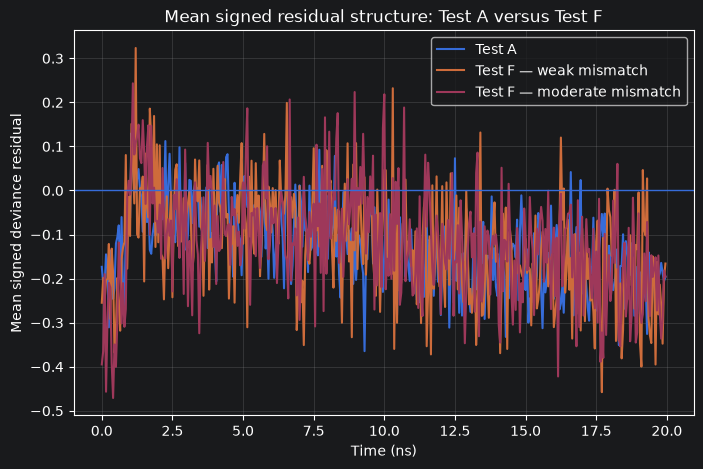

In [16]:
profile_table = (
    residual_report
    .profile_table
)

display(
    profile_table.head()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    profile_table["time_ns"],
    profile_table["A_mean_signed_residual"],
    label="Test A",
)

ax.plot(
    profile_table["time_ns"],
    profile_table["F_weak_mean_signed_residual"],
    label="Test F — weak mismatch",
)

ax.plot(
    profile_table["time_ns"],
    profile_table["F_moderate_mean_signed_residual"],
    label="Test F — moderate mismatch",
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_xlabel(
    "Time (ns)"
)

ax.set_ylabel(
    "Mean signed deviance residual"
)

ax.set_title(
    "Mean signed residual structure: Test A versus Test F"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.show()

In [17]:
interval_scorecard = (
    ml_uncertainty_report
    .interval_scorecard
)

coverage_pivot = (
    interval_scorecard
    .pivot(
        index="test_id",
        columns="method",
        values="empirical_coverage",
    )
)

width_pivot = (
    interval_scorecard
    .pivot(
        index="test_id",
        columns="method",
        values="mean_width_ns",
    )
)

print(
    "Conformal correction:",
    conformal_calibration
    .correction_ns,
    "ns",
)

print(
    "\nCoverage:"
)

display(
    coverage_pivot.round(4)
)

print(
    "\nMean interval width (ns):"
)

display(
    width_pivot.round(4)
)

Conformal correction: 0.0 ns

Coverage:


method,conformalized_quantile_gradient_boosting,quantile_gradient_boosting
test_id,,
A,1.0,1.0
B,1.0,1.0
C,1.0,1.0
D,1.0,1.0
E,1.0,1.0
F,1.0,1.0



Mean interval width (ns):


method,conformalized_quantile_gradient_boosting,quantile_gradient_boosting
test_id,,
A,2.4583,2.4583
B,2.6719,2.6719
C,2.4688,2.4688
D,2.6406,2.6406
E,2.4688,2.4688
F,2.4844,2.4844


## Scientific synthesis

Week 9 demonstrates that uncertainty is not a single estimator-independent
quantity.

Direct quantile gradient boosting produces conservative nominal 90%
prediction intervals on the current small development dataset. Their broad
width gives high coverage but weak failure discrimination, particularly
under controlled bi-exponential model mismatch.

Random-Forest tree disagreement is the strongest current sample-level ML
failure-ranking signal. It remains informative under several acquisition
shifts, but its magnitude is not a calibrated lifetime standard deviation
and it is not a general test of physical model validity.

Training-data bootstrap spread for Ridge responds strongly to several
acquisition-distribution shifts but can rank individual errors poorly.
Because all bootstrap replicas remain inside the mono-exponential training
distribution, their agreement does not imply physical-model validity.

Under a correctly specified mono-exponential reconvolution model, both
local Poisson/Fisher covariance and parametric Poisson bootstrap reproduce
repeated-Poisson sampling variability reasonably well. Their uncertainty
increases appropriately when photon information is reduced or background
is increased.

The central failure occurs under bi-exponential Test F. Classical lifetime
error increases substantially while covariance and bootstrap uncertainty
change only modestly, causing nominal 90% interval coverage to collapse.
Both methods correctly quantify statistical variability conditional on the
assumed mono-exponential model while remaining unaware that this model is
wrong.

Split conformalization does not alter the current quantile intervals because
all held-out calibration targets already lie inside the original broad
intervals. In this experiment, conformal calibration therefore cannot add
model-mismatch awareness.

Finally, scalar Poisson deviance is almost insensitive to the controlled
model mismatch, while aggregated signed residual profiles provide only weak
additional discrimination and no clear severity-dependent temporal
signature.

The principal Week 9 conclusion is therefore:

> **An estimator can know how uncertain it is about statistical noise while
> remaining unaware that its physical model is wrong.**

Robust TCSPC inference should consequently combine statistical uncertainty
with explicit distribution-shift and model-validity diagnostics rather than
treating a single uncertainty value as a universal measure of trust.